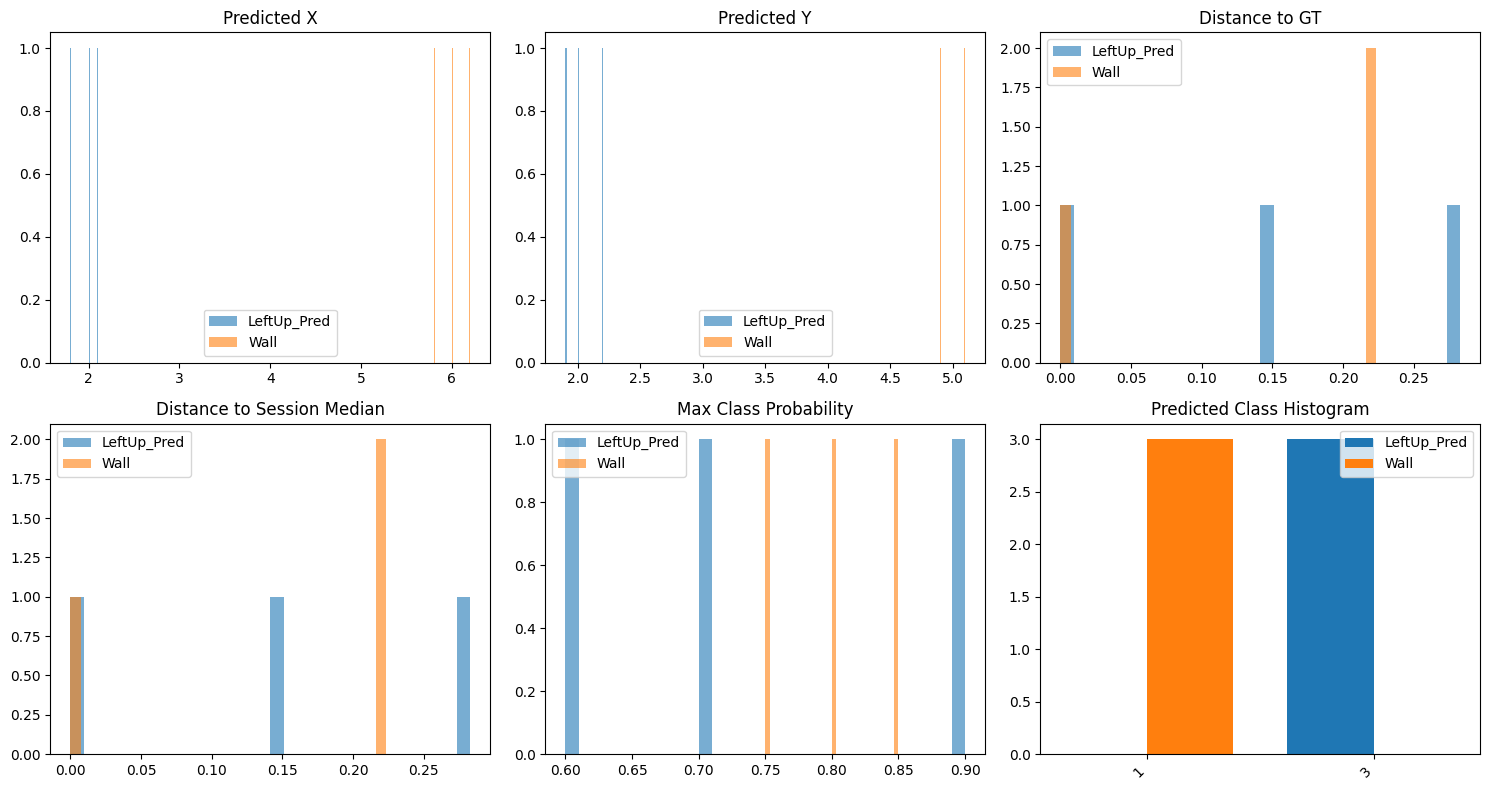

LeftUp_Pred median xy: [2. 2.] median error: 0.0
Wall        median xy: [6. 5.] median error: 0.0


<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ---- set your GT here ----
GT = {
    "LeftUp_Pred": np.array([2.0, 2.0], dtype=float),
    "Wall":        np.array([6.0, 5.0], dtype=float),
}

# optional: put your semantic class names here if available
CLASS_NAMES = None
# example:
# CLASS_NAMES = ["Empty","LeftDown","LeftMid","LeftUp","MiddleDown","MiddleUp","RightDown","RightMid","RightUp"]

def session_stats(name, data):
    coords = np.asarray(data["coords"], dtype=float)   # [N,2]
    probs  = np.asarray(data["probs"], dtype=float)    # [N,C]
    cls    = np.asarray(data["cls"])                   # [N]

    gt = GT[name]
    med = np.median(coords, axis=0)

    dist_to_gt = np.linalg.norm(coords - gt, axis=1)
    dist_to_med = np.linalg.norm(coords - med, axis=1)
    conf = probs.max(axis=1) if probs.ndim == 2 else None

    return {
        "coords": coords,
        "cls": cls,
        "conf": conf,
        "dist_to_gt": dist_to_gt,
        "dist_to_med": dist_to_med,
        "median_xy": med,
        "median_err": np.linalg.norm(med - gt),
    }

# ensure RESULTS exists with expected keys
if "RESULTS" not in globals():
    # replace this synthetic data with your real inference outputs
    RESULTS = {
        "LeftUp_Pred": {
            "coords": np.array([[1.8, 2.2], [2.1, 1.9], [2.0, 2.0]], dtype=float),
            "probs": np.array([[0.7, 0.3], [0.6, 0.4], [0.9, 0.1]], dtype=float),
            "cls": np.array([3, 3, 3]),
        },
        "Wall": {
            "coords": np.array([[5.8, 5.1], [6.2, 4.9], [6.0, 5.0]], dtype=float),
            "probs": np.array([[0.8, 0.2], [0.75, 0.25], [0.85, 0.15]], dtype=float),
            "cls": np.array([1, 1, 1]),
        },
    }

S_left = session_stats("LeftUp_Pred", RESULTS["LeftUp_Pred"])
S_wall = session_stats("Wall", RESULTS["Wall"])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1) predicted x
axes[0,0].hist(S_left["coords"][:,0], bins=30, alpha=0.6, label="LeftUp_Pred")
axes[0,0].hist(S_wall["coords"][:,0], bins=30, alpha=0.6, label="Wall")
axes[0,0].set_title("Predicted X")
axes[0,0].legend()

# 2) predicted y
axes[0,1].hist(S_left["coords"][:,1], bins=30, alpha=0.6, label="LeftUp_Pred")
axes[0,1].hist(S_wall["coords"][:,1], bins=30, alpha=0.6, label="Wall")
axes[0,1].set_title("Predicted Y")
axes[0,1].legend()

# 3) distance to GT
axes[0,2].hist(S_left["dist_to_gt"], bins=30, alpha=0.6, label="LeftUp_Pred")
axes[0,2].hist(S_wall["dist_to_gt"], bins=30, alpha=0.6, label="Wall")
axes[0,2].set_title("Distance to GT")
axes[0,2].legend()

# 4) distance to session median
axes[1,0].hist(S_left["dist_to_med"], bins=30, alpha=0.6, label="LeftUp_Pred")
axes[1,0].hist(S_wall["dist_to_med"], bins=30, alpha=0.6, label="Wall")
axes[1,0].set_title("Distance to Session Median")
axes[1,0].legend()

# 5) confidence
if S_left["conf"] is not None and S_wall["conf"] is not None:
    axes[1,1].hist(S_left["conf"], bins=30, alpha=0.6, label="LeftUp_Pred")
    axes[1,1].hist(S_wall["conf"], bins=30, alpha=0.6, label="Wall")
    axes[1,1].set_title("Max Class Probability")
    axes[1,1].legend()
else:
    axes[1,1].axis("off")

# 6) class histogram
left_counts = Counter(S_left["cls"].tolist())
wall_counts = Counter(S_wall["cls"].tolist())

all_keys = sorted(set(left_counts.keys()) | set(wall_counts.keys()))
left_vals = [left_counts.get(k, 0) for k in all_keys]
wall_vals = [wall_counts.get(k, 0) for k in all_keys]

x = np.arange(len(all_keys))
w = 0.38
axes[1,2].bar(x - w/2, left_vals, width=w, label="LeftUp_Pred")
axes[1,2].bar(x + w/2, wall_vals, width=w, label="Wall")
axes[1,2].set_title("Predicted Class Histogram")
axes[1,2].set_xticks(x)

if CLASS_NAMES is not None:
    axes[1,2].set_xticklabels([CLASS_NAMES[int(k)] for k in all_keys], rotation=45, ha="right")
else:
    axes[1,2].set_xticklabels(all_keys, rotation=45, ha="right")

axes[1,2].legend()

plt.tight_layout()
plt.show()

print("LeftUp_Pred median xy:", S_left["median_xy"], "median error:", S_left["median_err"])
print("Wall        median xy:", S_wall["median_xy"], "median error:", S_wall["median_err"])

#save
plt.savefig("session_analysis.png")